# ✅ Solutions — Session 4: Styling & Colormaps

Worked solutions to all five exercises and the mini project.
Run each cell top to bottom.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

## Exercise 1 (Easy) — Named vs. hex, dashed vs. dotted

Plot `y = x**2` twice with different colors and line styles, and add a legend.

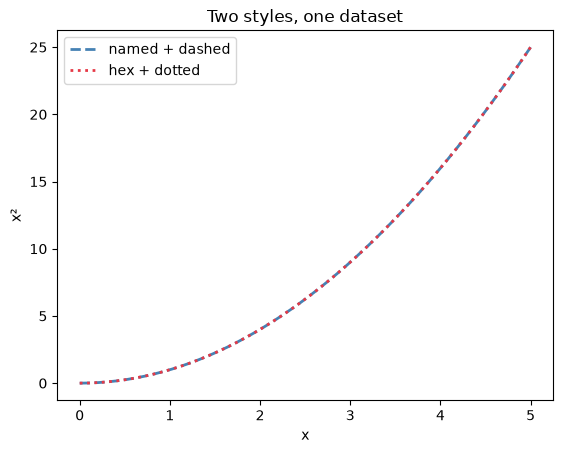

In [2]:
x = np.linspace(0, 5, 50)
y = x ** 2

fig, ax = plt.subplots()
ax.plot(x, y, color="steelblue", linestyle="--", linewidth=2, label="named + dashed")
ax.plot(x, y, color="#e63946", linestyle=":", linewidth=2, label="hex + dotted")
ax.set_title("Two styles, one dataset")
ax.set_xlabel("x")
ax.set_ylabel("x²")
ax.legend()
plt.show()

## Exercise 2 (Easy) — Inspect and apply style sheets

Count the available themes, print the first five, then render one chart under
two different style contexts.

Number of style sheets: 28
First five: ['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast']


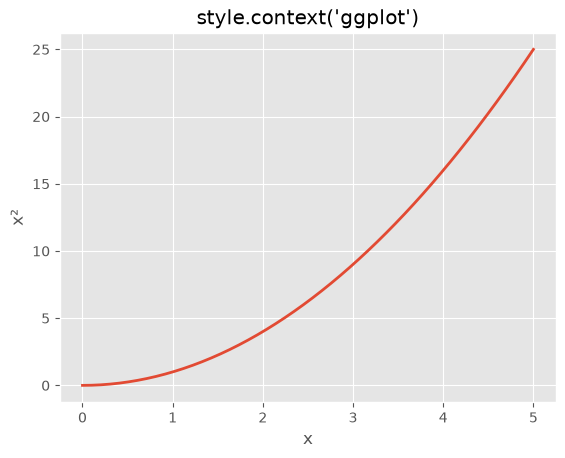

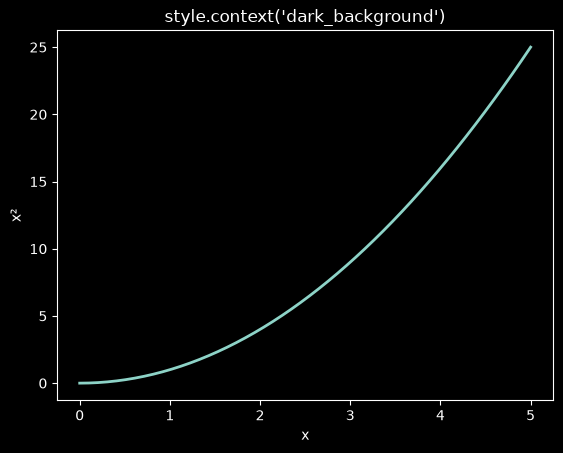

In [3]:
print("Number of style sheets:", len(plt.style.available))
print("First five:", plt.style.available[:5])

for theme in ["ggplot", "dark_background"]:
    with plt.style.context(theme):
        fig, ax = plt.subplots()
        ax.plot(x, x ** 2, linewidth=2)
        ax.set_title(f"style.context('{theme}')")
        ax.set_xlabel("x")
        ax.set_ylabel("x²")
        plt.show()

## Exercise 3 (Medium, coding) — Colored scatter with `alpha` and a colorbar

Sample 1000 points from a 2D normal distribution, color them by distance from
the origin, and attach a labeled colorbar.

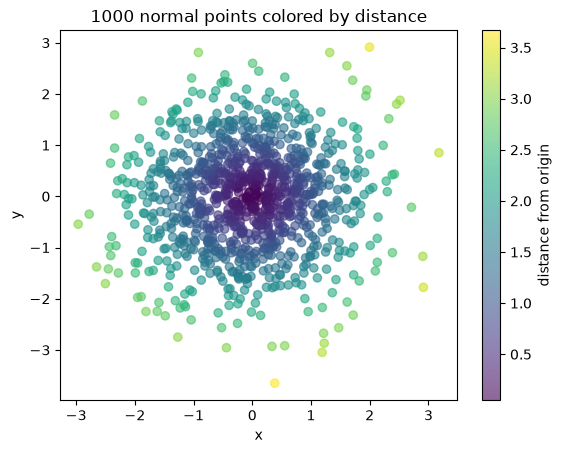

In [4]:
rng = np.random.default_rng(42)
points = rng.normal(size=(1000, 2))
xs, ys = points[:, 0], points[:, 1]
distance = np.hypot(xs, ys)

fig, ax = plt.subplots()
sc = ax.scatter(xs, ys, c=distance, cmap="viridis", alpha=0.6)
fig.colorbar(sc, ax=ax, label="distance from origin")
ax.set_title("1000 normal points colored by distance")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

## Exercise 4 (Medium) — Display a matrix with `imshow` and a colorbar

Show a 12×12 random matrix with `origin='lower'`, the `magma` colormap, and a
title that reports the array's shape.

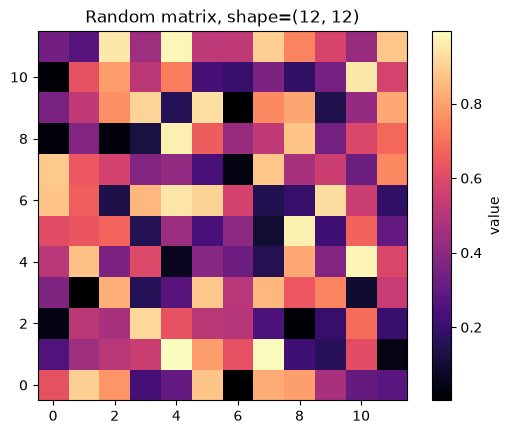

In [5]:
Z = np.random.default_rng(7).random((12, 12))

fig, ax = plt.subplots()
im = ax.imshow(Z, origin="lower", cmap="magma")
fig.colorbar(im, ax=ax, label="value")
ax.set_title(f"Random matrix, shape={Z.shape}")
plt.show()

## Exercise 5 (Advanced, conceptual) — `imshow` vs. `pcolormesh`

`imshow` treats the array as a regular raster: pixels are evenly spaced and the
x/y coordinates are implicit (equally spaced indices, or the bounds given by
`extent`). It is the natural choice for an actual image or a plain matrix where
row and column spacing is uniform.

`pcolormesh` draws quadrilaterals at explicit coordinates, so the x and y
arrays may be non-uniform. Reach for it when the grid is irregular, when cell
edges matter, or when you need the axes to show true data coordinates.

- **`imshow` example:** a grayscale photo loaded as a 2D array, or a correlation
  matrix where every cell is one equal-sized row/column pair.
- **`pcolormesh` example:** a grid of weather-station temperatures at unevenly
  spaced longitudes and latitudes, or a spectrogram with logarithmic
  frequency bins.

## 🚀 Mini Project — Chart Makeover

Turn a plain sine-wave chart into a polished figure: style sheet, recolored
thick line, markers, a shaded region, a bold title, and a saved PNG that is
removed afterward.

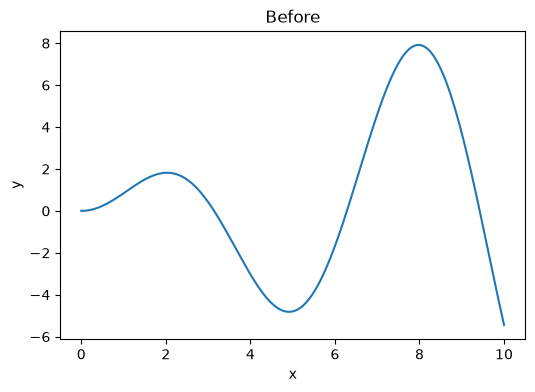

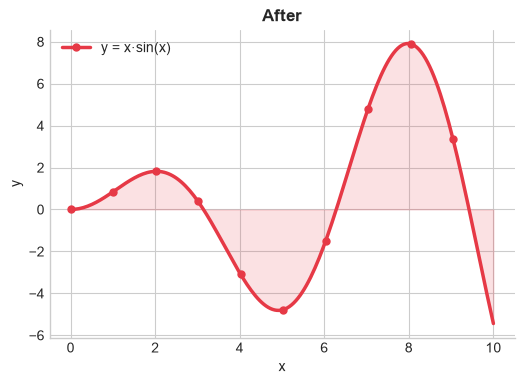

In [6]:
import os

mx = np.linspace(0, 10, 200)
my = np.sin(mx) * mx

# ---- "Before": completely default ----
fig_before, ax_before = plt.subplots(figsize=(6, 4))
ax_before.plot(mx, my)
ax_before.set_title("Before")
ax_before.set_xlabel("x")
ax_before.set_ylabel("y")
plt.show()

# ---- "After": fully styled ----
with plt.style.context("seaborn-v0_8-whitegrid"):
    fig_after, ax_after = plt.subplots(figsize=(6, 4))
    ax_after.plot(mx, my, color="#e63946", linewidth=2.5,
                  marker="o", markersize=5, markevery=20,
                  label="y = x·sin(x)")
    ax_after.fill_between(mx, my, alpha=0.15, color="#e63946")
    ax_after.set_title("After", fontweight="bold")
    ax_after.set_xlabel("x")
    ax_after.set_ylabel("y")
    ax_after.legend()
    ax_after.spines["top"].set_visible(False)
    ax_after.spines["right"].set_visible(False)
    plt.show()

### Side-by-side comparison

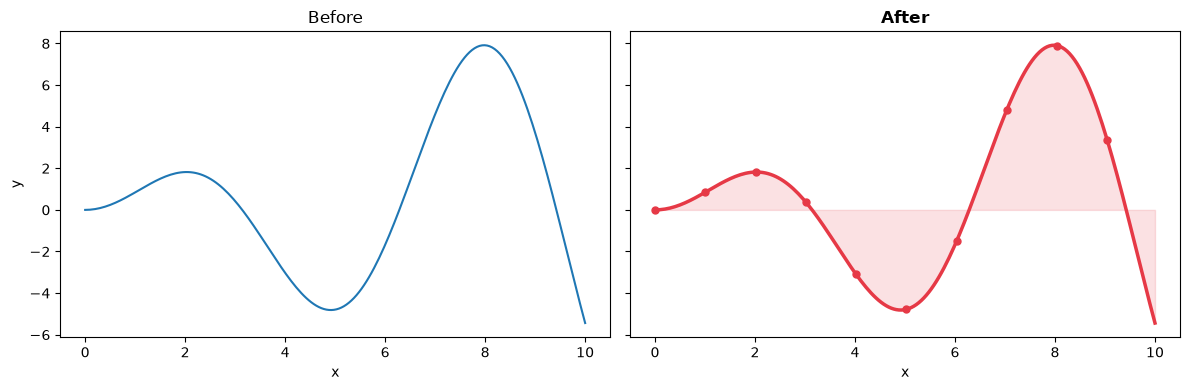

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].plot(mx, my)
axes[0].set_title("Before")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

axes[1].plot(mx, my, color="#e63946", linewidth=2.5,
             marker="o", markersize=5, markevery=20)
axes[1].fill_between(mx, my, alpha=0.15, color="#e63946")
axes[1].set_title("After", fontweight="bold")
axes[1].set_xlabel("x")
fig.tight_layout()
plt.show()

### Save at publication quality, then clean up

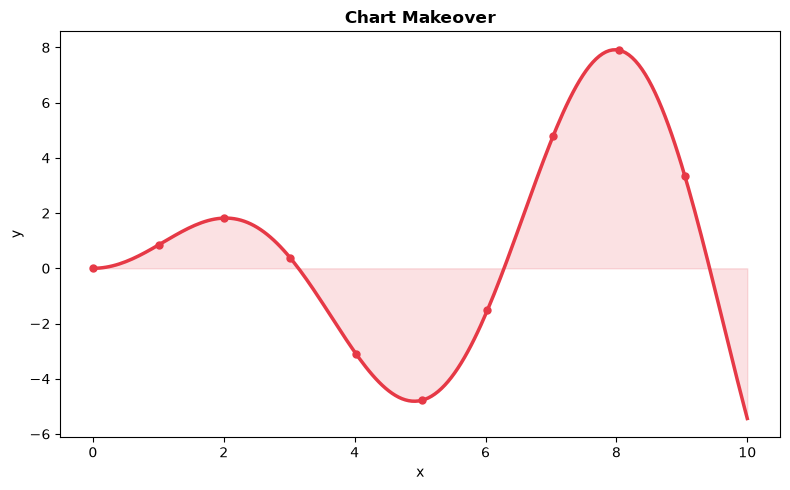

Saved and removed chart_makeover.png


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(mx, my, color="#e63946", linewidth=2.5,
        marker="o", markersize=5, markevery=20)
ax.fill_between(mx, my, alpha=0.15, color="#e63946")
ax.set_title("Chart Makeover", fontweight="bold")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.tight_layout()
fig.savefig("chart_makeover.png", dpi=150, bbox_inches="tight")
plt.show()

os.remove("chart_makeover.png")
print("Saved and removed chart_makeover.png")